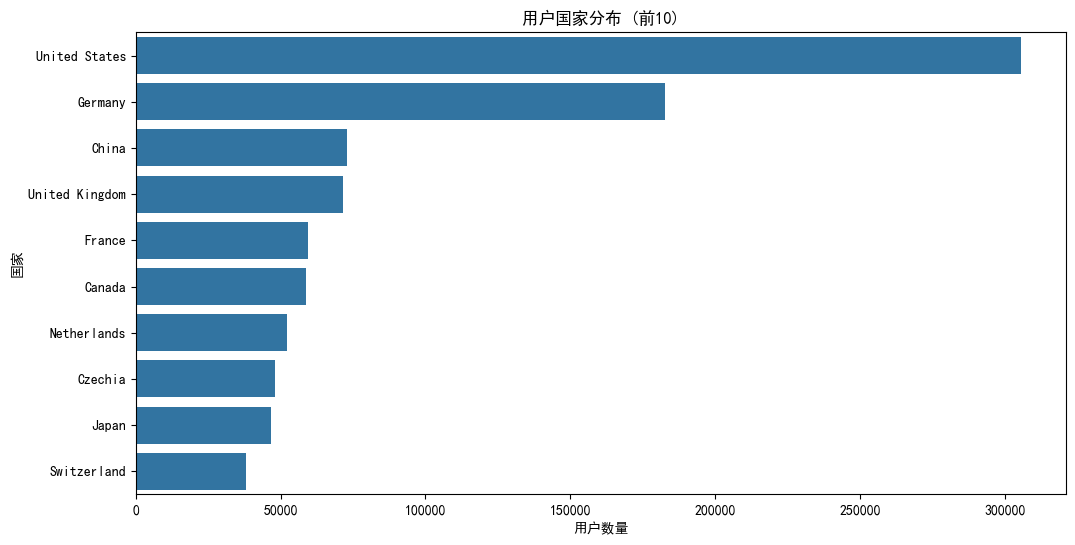

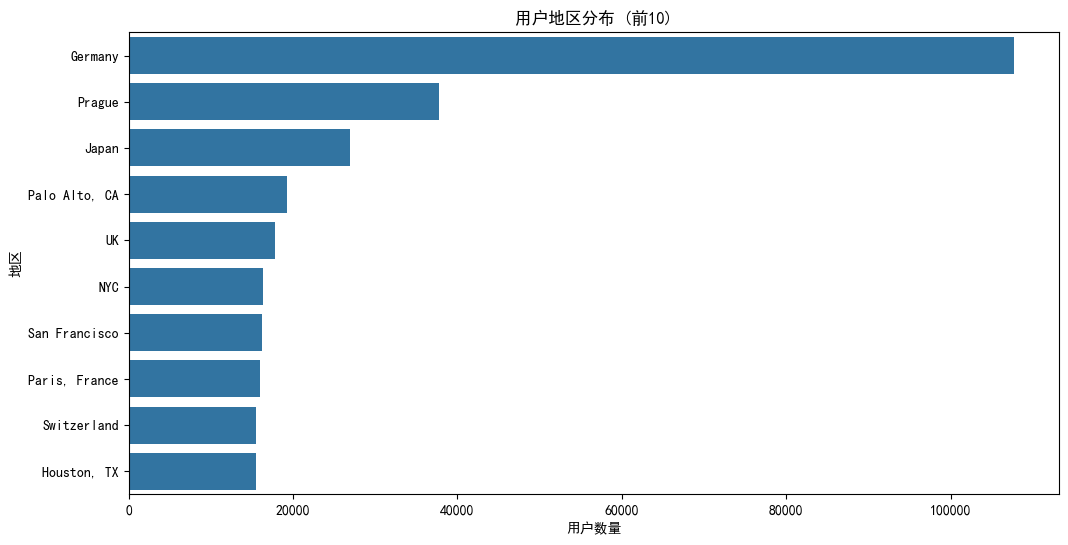

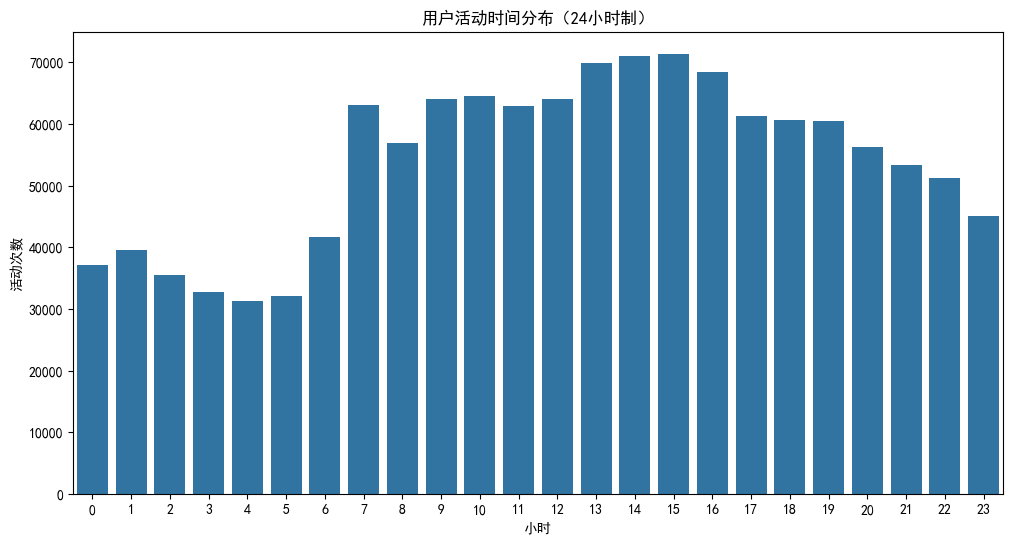

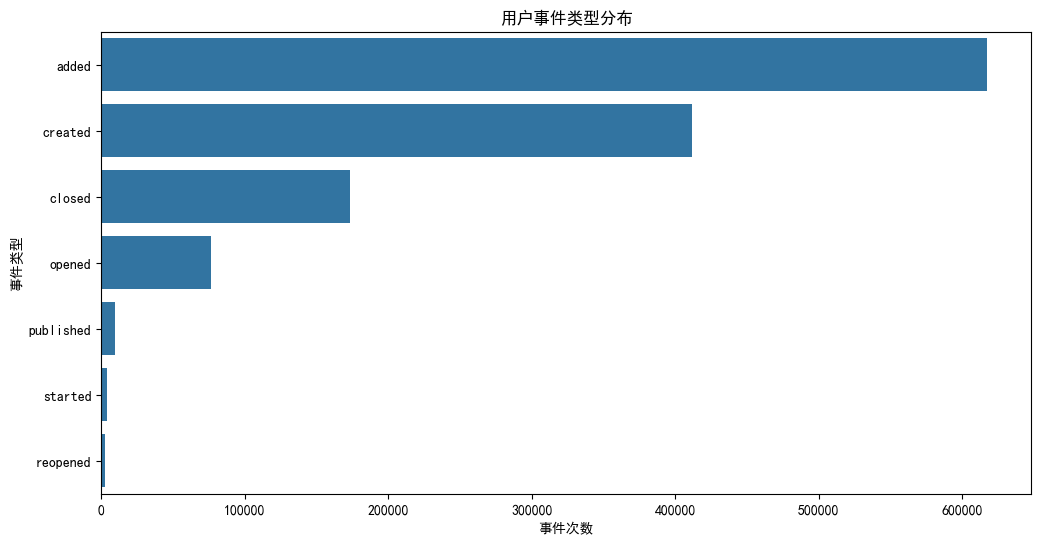

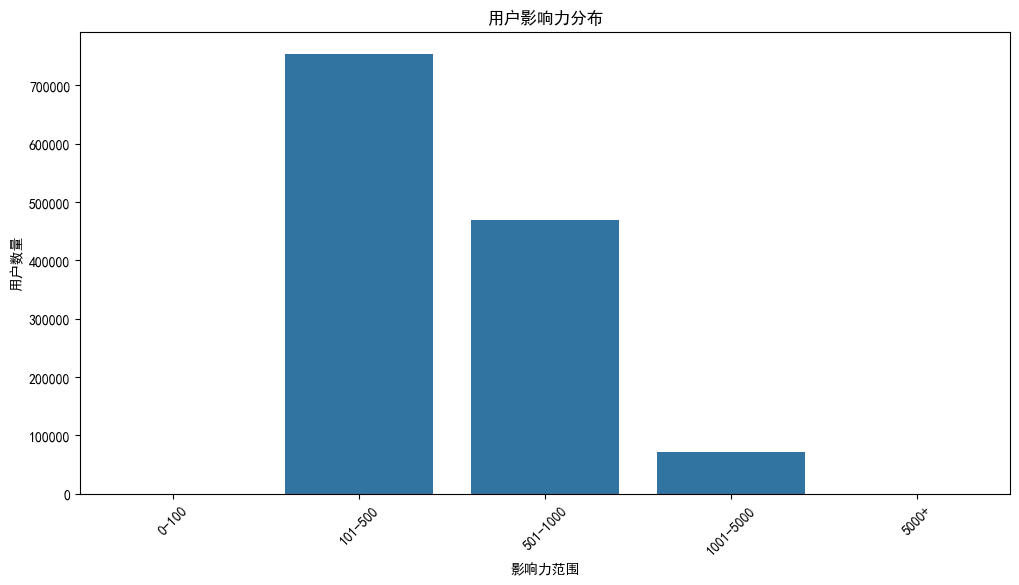

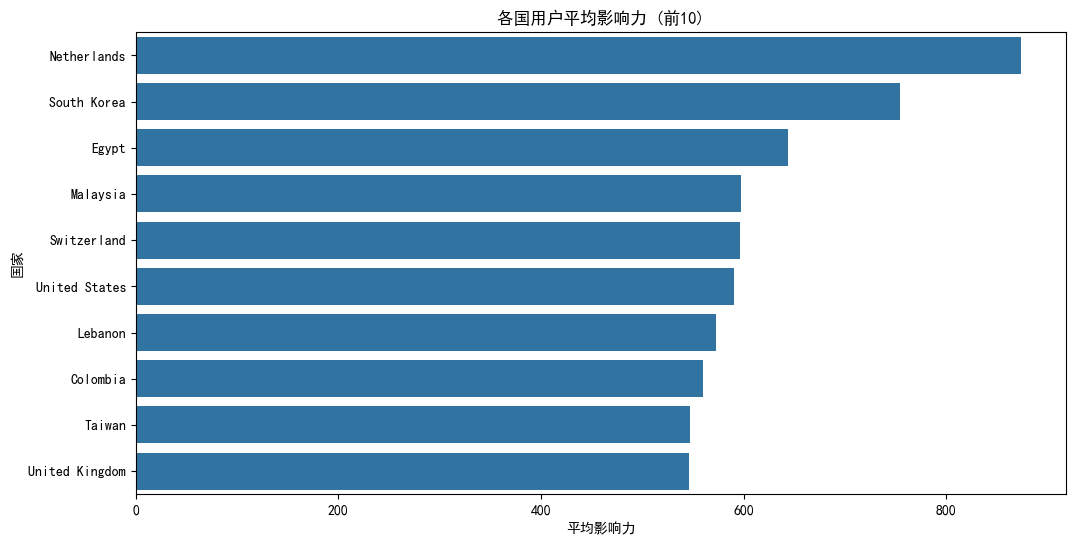

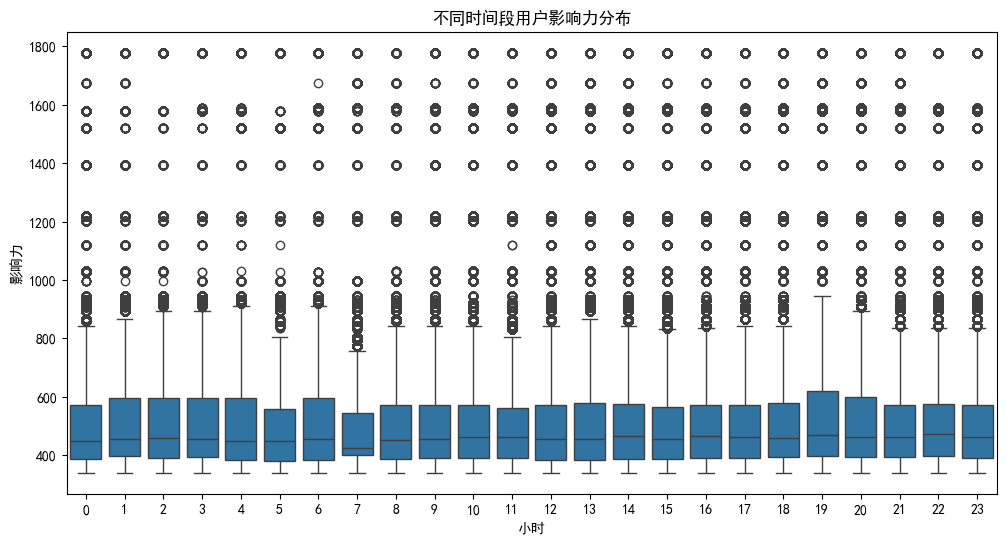


数据分析总结：
总用户数：497
活跃国家数：52
活跃地区数：344

事件类型统计：
event_action
added        617218
created      411961
closed       173489
opened        76406
published      9455
started        3809
reopened       2438
Name: count, dtype: int64

平均用户影响力：544.09
最高用户影响力：1776.97

最活跃时间段：15:00

最具影响力的前5个国家：
country
Netherlands    874.232403
South Korea    754.195618
Egypt          644.220337
Malaysia       597.661397
Switzerland    596.237744
Name: total_influence, dtype: float64


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

c:\Users\15249\AppData\Local\Programs\Python\Python312\Lib\site-packages\ydata_profiling\model\pandas\discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[8 8 1 ... 3 6 3]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import ydata_profiling as yp
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False     # 解决负号显示问题

# 读取所有CSV文件
file_paths = [
    r'D:\Coding\project\myproject\jupyter_notebook\users_combined_info_500_part_1.csv',
    r'D:\Coding\project\myproject\jupyter_notebook\users_combined_info_500_part_2.csv',
    r'D:\Coding\project\myproject\jupyter_notebook\users_combined_info_500_part_3.csv',
    r'D:\Coding\project\myproject\jupyter_notebook\users_combined_info_500_part_4.csv',
    r'D:\Coding\project\myproject\jupyter_notebook\users_combined_info_500_part_5.csv',
    r'D:\Coding\project\myproject\jupyter_notebook\users_combined_info_500_part_6.csv',
    r'D:\Coding\project\myproject\jupyter_notebook\users_combined_info_500_part_7.csv',
]

# 合并数据
dfs = []
for file in file_paths:
    try:
        df_temp = pd.read_csv(file)
        dfs.append(df_temp)
    except Exception as e:
        print(f"读取文件 {file} 时出错: {e}")

df = pd.concat(dfs, ignore_index=True, axis=0)

# 1. 人口统计分析
# 1.1 国家分布
plt.figure(figsize=(12, 6))
country_counts = df['country'].value_counts().head(10)
sns.barplot(x=country_counts.values, y=country_counts.index)
plt.title('用户国家分布 (前10)')
plt.xlabel('用户数量')
plt.ylabel('国家')
plt.show()

# 1.2 地区分布
plt.figure(figsize=(12, 6))
location_counts = df['location'].value_counts().head(10)
sns.barplot(x=location_counts.values, y=location_counts.index)
plt.title('用户地区分布 (前10)')
plt.xlabel('用户数量')
plt.ylabel('地区')
plt.show()

# 1.3 时间分析（基于event_time）
# 将event_time转换为datetime类型
df['event_time'] = pd.to_datetime(df['event_time'])
df['hour'] = df['event_time'].dt.hour

# 分析用户活动时间分布
plt.figure(figsize=(12, 6))
hour_counts = df['hour'].value_counts().sort_index()
sns.barplot(x=hour_counts.index, y=hour_counts.values)
plt.title('用户活动时间分布（24小时制）')
plt.xlabel('小时')
plt.ylabel('活动次数')
plt.show()

# 2. 协作行为分析
# 2.1 事件类型分布
plt.figure(figsize=(12, 6))
event_counts = df['event_action'].value_counts()
sns.barplot(x=event_counts.values, y=event_counts.index)
plt.title('用户事件类型分布')
plt.xlabel('事件次数')
plt.ylabel('事件类型')
plt.show()

# 2.2 用户影响力分析
plt.figure(figsize=(12, 6))
influence_bins = [0, 100, 500, 1000, 5000, float('inf')]
df['influence_category'] = pd.cut(df['total_influence'], bins=influence_bins, 
                                labels=['0-100', '101-500', '501-1000', '1001-5000', '5000+'])
influence_dist = df['influence_category'].value_counts()
sns.barplot(x=influence_dist.index, y=influence_dist.values)
plt.title('用户影响力分布')
plt.xlabel('影响力范围')
plt.ylabel('用户数量')
plt.xticks(rotation=45)
plt.show()

# 3. 其他维度分析
# 3.1 按国家的平均影响力分析
country_influence = df.groupby('country')['total_influence'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=country_influence.values, y=country_influence.index)
plt.title('各国用户平均影响力 (前10)')
plt.xlabel('平均影响力')
plt.ylabel('国家')
plt.show()

# 3.2 活动时间与影响力关系分析
plt.figure(figsize=(12, 6))
sns.boxplot(x='hour', y='total_influence', data=df)
plt.title('不同时间段用户影响力分布')
plt.xlabel('小时')
plt.ylabel('影响力')
plt.show()

# 输出统计信息
print("\n数据分析总结：")
print(f"总用户数：{len(df['name'].unique())}")
print(f"活跃国家数：{df['country'].nunique()}")
print(f"活跃地区数：{df['location'].nunique()}")
print("\n事件类型统计：")
print(df['event_action'].value_counts())
print("\n平均用户影响力：{:.2f}".format(df['total_influence'].mean()))
print("最高用户影响力：{:.2f}".format(df['total_influence'].max()))

# 计算最活跃的时间段
peak_hour = df['hour'].value_counts().index[0]
print(f"\n最活跃时间段：{peak_hour}:00")

# 输出最具影响力的前5个国家
top_countries = df.groupby('country')['total_influence'].mean().sort_values(ascending=False).head(5)
print("\n最具影响力的前5个国家：")
print(top_countries)
# 生成交互式数据分析报告
profile = yp.ProfileReport(df, title='Pandas Profiling Report')
profile.to_file("output2.html")